# HALO-AC3 Arctic Leads Batch Processing
This notebook demonstrates batch processing of HALO-AC3 data using PyRadtran.

In [1]:
# Import PyRadtran components
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pathlib import Path
import os
import yaml
import pandas as pd

# Load the configuration from the YAML file
config_path = Path('../config/HALO-AC3_HALO_solar_disort.yaml')
import logging
# Configure logging for pyradtran
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

## Load and prepare data
Load the BBR data and surface type information from Nils Risse's dataset

In [2]:
# ds_bbr = bbr_halo = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bbr_HALO.nc')
# surface_type = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/Nils_Risse/data/HALO-AC3_VELOX_surface_type_fraction_full_FOV.nc').drop_duplicates(dim='time', keep='last')
# surface_type_5deg = surface_type['histogram_label']
# max_surface_type = surface_type_5deg.argmax(dim='label_bin')
# surface_type['surface_max_frac'] = surface_type_5deg.max(dim='label_bin')


# ds_bbr = ds_bbr.interp_like(surface_type['time'])

# ds_bbr['surface_type'] = max_surface_type
# ds_bbr['surface_type_max_frac'] = surface_type['surface_max_frac']
# ds_bbr['surface_type_max_frac'].plot.hist(bins=20, histtype='step', color='C0', alpha=0.5, label='Max surface type fraction', figsize=(3, 1))
# ds_bbr = ds_bbr.where(ds_bbr['surface_type_max_frac'] > 0.9, drop=True)

In [3]:
ds_bbr = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bbr_HALO_clear_sky_with_ocean.nc').drop_duplicates(dim='time', keep='last').sortby('time')


## Prepare a cropped dataset for efficient processing
Create a coarsened subset for faster simulations

In [4]:
ds_crop = ds_bbr[['time', 'lat', 'lon', 'alt']].resample(time='600S').mean().dropna('time').rename(
    {'lat': 'latitude', 'lon': 'longitude'}
)

ds_crop['time'] = ds_crop['time'].dt.round('1s')
ds_crop['altitude'] = np.arange(0, 15, 1)
ds_crop

/home/jomueller/micromamba/envs/mamba_josh/lib/python3.12/site-packages/xarray/groupers.py:392: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  self.index_grouper = pd.Grouper(


<xarray.Dataset> Size: 5kB
Dimensions:    (time: 149, altitude: 15)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2022-03-14T10:30:00 ... 2022-04-11T1...
  * altitude   (altitude) int64 120B 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14
Data variables:
    latitude   (time) float64 1kB 79.38 82.61 81.79 80.14 ... 84.94 85.93 85.46
    longitude  (time) float64 1kB 27.16 3.475 1.575 4.314 ... 9.461 16.73 12.38
    alt        (time) float64 1kB 1.095e+04 1.169e+04 ... 1.153e+04 8.931e+03
Attributes:
    title:                Broadband radiation measured by BACARDI during HALO...
    mission:              HALO-AC3
    platform:             HALO
    instrument:           BACARDI
    research_flight_day:  2022/04/08
    version:              R1
    date_last_revised:    2023/10/25
    comment:              BACARDI raw data was processed by DLR; contact Andr...
    contact:              Anna Luebke, Andre Ehrlich, University Leipzig; ema...

## Add albedo values to the dataset
Add albedo as a coordinate variable based on surface types

In [5]:
# # Map surface types to typical albedo values for Arctic surfaces
# surface_albedo_map = {
#     0: 0.07,  # Open water
#     1: 0.30,  # Nilas/gray ice
#     2: 0.60,  # Young white ice
#     3: 0.80   # Thick first-year ice
# }

# # Function to find the nearest surface type for a timestamp
# def get_nearest_surface_type(time):
#     # Convert to pandas Timestamp for easier comparison
#     pd_time = pd.Timestamp(time.values)
    
#     # Find the closest time in the original dataset
#     time_diffs = abs(pd.DatetimeIndex(ds_bbr.time.values) - pd_time)
#     closest_idx = time_diffs.argmin()
    
#     # Get the surface type for that time
#     return ds_bbr.surface_type.values[closest_idx]

# # Get surface types for each time point in the crop dataset
# surface_types = np.array([get_nearest_surface_type(t) for t in ds_crop.time])
# albedo_values = np.array([surface_albedo_map.get(int(st), 0.6) for st in surface_types])

# ds_crop['albedo'] = (('time',), albedo_values)

# # Print the result to verify
# print("Surface types for the crop times:", surface_types)
# print("Corresponding albedo values:", albedo_values)
# ds_crop

(array([ 1.,  3.,  1.,  5.,  3.,  6.,  0.,  1.,  1.,  1.,  2.,  3.,  6.,
         6., 16., 13., 19.,  7.,  4.,  1.]),
 array([0.14629463, 0.18561175, 0.22492887, 0.26424599, 0.30356311,
        0.34288023, 0.38219735, 0.42151447, 0.46083159, 0.50014872,
        0.53946584, 0.57878296, 0.61810008, 0.6574172 , 0.69673432,
        0.73605144, 0.77536856, 0.81468568, 0.85400281, 0.89331993,
        0.93263705]),
 [<matplotlib.patches.Polygon at 0x7f8fa7ad9940>])

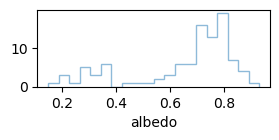

In [6]:
ds_crop['albedo'] = ds_bbr['albedo'].interp_like(ds_crop['time'])
ds_crop['albedo'] = ds_crop['albedo'].where(ds_crop['albedo'] < 1, drop=True)
ds_crop['albedo'].plot.hist(bins=20, histtype='step', color='C0', alpha=0.5, label='Albedo', figsize=(3, 1))

## Run the simulation
Use the PyRadtran accessor to run a simulation using the dataset with albedo values

In [7]:
# Run a spectral simulation for the dataset
print("Running batch spectral simulation...")
ds_sim = ds_crop.pyradtran.run_uvspec(
    config_path=config_path,
    return_dataset=True,
    save_to_file=True,
    output_path='../work/halo_ac3_results.nc',
    albedo_var='albedo',
)

print("\nSimulation complete!")
ds_sim

2025-05-08 11:35:53,235 - pyradtran.interface - INFO - Overriding configuration altitude with 15 levels from dataset: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
2025-05-08 11:35:53,235 - pyradtran.utils - INFO - Scanning for radiosondes under: /projekt_agmwend/data/HALO-AC3/01_soundings/RS_for_libradtran/Dropsondes_HALO
2025-05-08 11:35:53,248 - pyradtran.utils - INFO - Found and parsed 323 radiosonde files.
2025-05-08 11:35:53,309 - pyradtran.interface - INFO - Running 149 simulations across time/location points...


Running batch spectral simulation...


2025-05-08 11:35:53,539 - pyradtran.core - DEBUG - Time 2022-03-14 13:50:00 -> Closest Sonde: 20220314_51225SOD.dat
2025-05-08 11:35:53,539 - pyradtran.core - DEBUG - Time 2022-03-14 10:30:00 -> Closest Sonde: 20220314_37586SOD.dat
2025-05-08 11:35:53,540 - pyradtran.core - DEBUG - Time 2022-03-14 14:00:00 -> Closest Sonde: 20220314_51225SOD.dat
2025-05-08 11:35:53,543 - pyradtran.core - DEBUG - Time 2022-03-14 15:20:00 -> Closest Sonde: 20220314_55054SOD.dat
2025-05-08 11:35:53,543 - pyradtran.core - DEBUG - Time 2022-03-16 09:20:00 -> Closest Sonde: 20220316_38817SOD.dat
2025-05-08 11:35:53,544 - pyradtran.core - DEBUG - Time 2022-03-16 09:30:00 -> Closest Sonde: 20220316_38817SOD.dat
2025-05-08 11:35:53,546 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/notebooks/work/uvspec_20220314_135000_aatgovzc.inp
2025-05-08 11:35:53,547 - pyradtran.core - DEBUG - Generated input file: /projekt_agmwend/home_rad/Joshua/HALO-


Simulation complete!


<xarray.Dataset> Size: 147kB
Dimensions:    (time: 149, altitude: 15)
Coordinates:
  * time       (time) datetime64[ns] 1kB 2022-03-14T10:30:00 ... 2022-04-11T1...
  * altitude   (altitude) float64 120B 0.0 1.0 2.0 3.0 ... 11.0 12.0 13.0 14.0
Data variables:
    latitude   (time) float64 1kB 79.38 82.61 81.79 80.14 ... 84.94 85.93 85.46
    longitude  (time) float64 1kB 27.16 3.475 1.575 4.314 ... 9.461 16.73 12.38
    zout       (time, altitude) float64 18kB 0.0 1.0 2.0 3.0 ... nan nan nan nan
    sza        (time, altitude) float64 18kB 69.99 69.99 69.99 ... nan nan nan
    edir       (time, altitude) float64 18kB 3.068e+05 3.258e+05 ... nan nan
    eglo       (time, altitude) float64 18kB 3.408e+05 3.571e+05 ... nan nan
    edn        (time, altitude) float64 18kB 3.402e+04 3.136e+04 ... nan nan
    eup        (time, altitude) float64 18kB 9.961e+04 1.011e+05 ... nan nan
    enet       (time, altitude) float64 18kB 2.412e+05 2.56e+05 ... nan nan
    albedo     (time, altitude) float64 18kB 0.2922 0.2831 0.2813 ... nan nan
Attributes:
    generated_by:     pyradtran
    altitude_levels:  15 levels (km): 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0,...

In [8]:
ds_sim_bbr['enet'].plot()

NameError: name 'ds_sim_bbr' is not defined

In [ ]:
ds_sim['edn']

<xarray.DataArray 'edn' (time: 149, altitude: 15)> Size: 18kB
array([[31770.71 , 29383.63 , 26875.8  , ...,  7590.281,  6557.448,
         5658.114],
       [28854.23 , 26717.25 , 24580.34 , ...,  7410.589,  6430.868,
         5571.432],
       [34810.32 , 31901.75 , 29109.56 , ...,  8281.763,  7158.756,
         6180.224],
       ...,
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan]])
Coordinates:
  * time      (time) datetime64[ns] 1kB 2022-03-14T10:30:00 ... 2022-04-11T12...
  * altitude  (altitude) float64 120B 0.0 1.0 2.0 3.0 ... 11.0 12.0 13.0 14.0
Attributes:
    units:    W m-2 nm-1

In [ ]:
# Load the solar flux data from Gueymard 2003 dataset
import pandas as pd

ds_e0 = pd.read_csv('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat', skiprows=22, sep='\s+', names=['wavelength', 'flux'], header=None).set_index('wavelength').to_xarray()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2628239/782123713.py:4: SyntaxWarning: invalid escape sequence '\s'
  ds_e0 = pd.read_csv('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat', skiprows=22, sep='\s+', names=['wavelength', 'flux'], header=None).set_index('wavelength').to_xarray()


In [ ]:
E0 = ds_e0['flux'].integrate('wavelength')
E0

<xarray.DataArray 'flux' ()> Size: 8B
array(1366151.1872347)

In [ ]:
ds_sim['transmittance'] = ds_sim['eglo'] / E0

(array([ 1.,  0.,  4.,  9.,  7.,  2.,  6., 15., 10., 21.,  7.,  4.,  4.,
         1.,  2.,  0.,  2.,  1.,  0.,  2.]),
 array([0.0626746 , 0.07973008, 0.09678556, 0.11384104, 0.13089653,
        0.14795201, 0.16500749, 0.18206297, 0.19911845, 0.21617393,
        0.23322941, 0.25028489, 0.26734038, 0.28439586, 0.30145134,
        0.31850682, 0.3355623 , 0.35261778, 0.36967326, 0.38672874,
        0.40378423]),
 [<matplotlib.patches.Polygon at 0x7fc3450da3c0>])

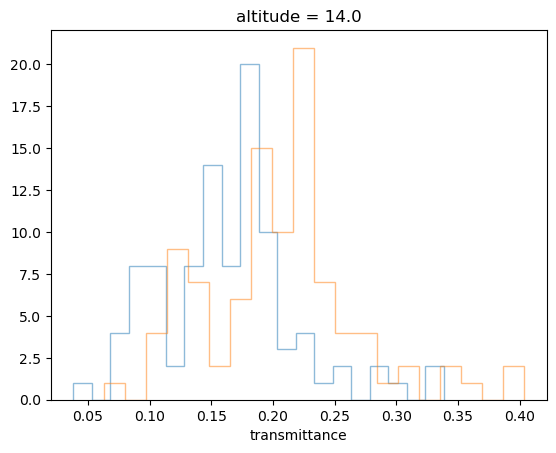

In [ ]:
ds_sim['transmittance'].isel(altitude=0).plot.hist(
    bins=20,
    histtype='step',
    color='C0',
    alpha=0.5,
)
ds_sim['transmittance'].isel(altitude=-1).plot.hist(
    bins=20,
    histtype='step',
    color='C1',
    alpha=0.5,
)

(array([ 15.,  42.,  33.,  74., 108.,  13.,  15.,  24.,  21.,  39.,  75.,
         98., 254., 276., 192., 106.,  57.,  18.,   8.,   2.]),
 array([0.1462946 , 0.18561172, 0.22492884, 0.26424596, 0.30356308,
        0.3428802 , 0.38219732, 0.42151444, 0.46083156, 0.50014868,
        0.5394658 , 0.57878292, 0.61810004, 0.65741716, 0.69673428,
        0.7360514 , 0.77536852, 0.81468564, 0.85400276, 0.89331988,
        0.932637  ]),
 [<matplotlib.patches.Polygon at 0x7fc3447d08c0>])

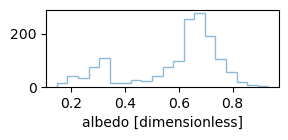

In [ ]:
ds_sim.albedo.plot.hist(bins=20, histtype='step', color='C0', alpha=0.5, label='Albedo', figsize=(3, 1))

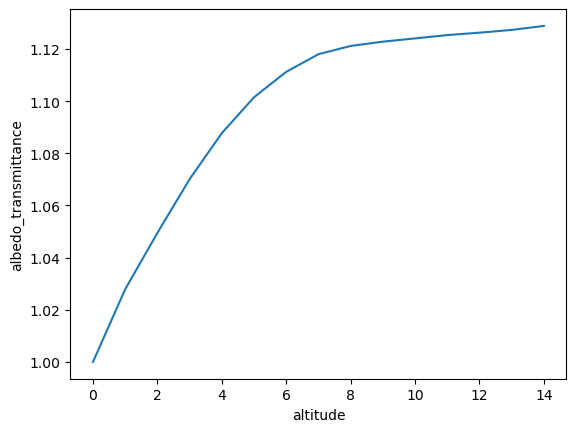

In [ ]:
ds_sim['albedo_transmittance'] = (ds_sim['albedo'].isel(altitude=0) / ds_sim['albedo'])
ds_sim['albedo_transmittance']
ds_sim['albedo_transmittance'].mean(dim='time').plot()

In [ ]:
ds_sim_ = ds_sim.sel(altitude=ds_crop['alt'], method='nearest').fillna(
    ds_sim['albedo_transmittance'].mean(dim='time').sel(altitude=ds_crop['alt'], method='nearest'
    ).values
)


ds_sim_bbr = ds_sim_.interp_like(ds_bbr['time'], method='nearest')
mean = ds_sim_bbr['albedo_transmittance'].mean(dim='time').values
ds_sim_bbr['albedo_transmittance'] = ds_sim_bbr['albedo_transmittance'].fillna(mean)


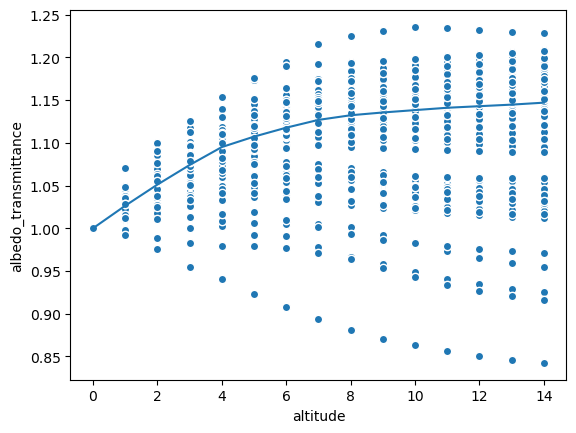

In [ ]:
ds_sim['albedo_transmittance'] = (ds_sim['albedo'].isel(altitude=0) / ds_sim['albedo'])
ds_sim['albedo_transmittance']
ds_sim['albedo_transmittance'].median(dim='time').plot()

ds_sim['albedo_transmittance'].plot.scatter(
    x = 'altitude', 
    y = 'albedo_transmittance',
)

2025-05-08 00:18:02,406 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-05-08 00:18:02,411 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<xarray.Dataset> Size: 240B
Dimensions:               (altitude: 15)
Coordinates:
  * altitude              (altitude) float64 120B 0.0 1.0 2.0 ... 12.0 13.0 14.0
Data variables:
    albedo_transmittance  (altitude) float64 120B 1.0 1.026 ... 1.145 1.147
Attributes:
    generated_by:     pyradtran
    altitude_levels:  15 levels (km): 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0,...

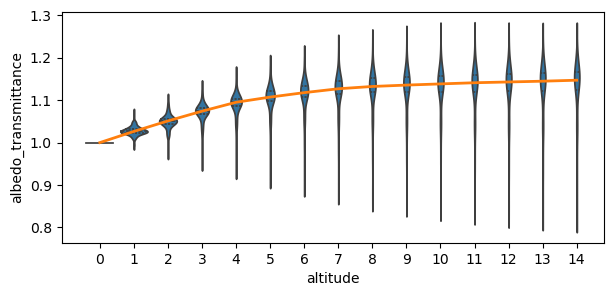

In [ ]:
import seaborn as sns

df = ds_sim.to_dataframe().reset_index()
df['altitude'] = df['altitude'].astype(int)

fig, ax = plt.subplots(figsize=(7, 3))
# make a violin plot

sns.violinplot(
    data=df,
    x='altitude',
    y='albedo_transmittance',
    inner='quartile',
    color='C0',
)

ax.plot(
    df['altitude'].unique(),
    df.groupby('altitude')['albedo_transmittance'].median(),
    color='C1',
    label='Median',
    linewidth=2,
)

albedo_transmittance = ds_sim[['albedo_transmittance']].groupby('altitude').median(dim='time')

albedo_transmittance


In [ ]:
albedo_transmittance

<xarray.Dataset> Size: 240B
Dimensions:               (altitude: 15)
Coordinates:
  * altitude              (altitude) float64 120B 0.0 1.0 2.0 ... 12.0 13.0 14.0
Data variables:
    albedo_transmittance  (altitude) float64 120B 1.0 1.026 ... 1.145 1.147
Attributes:
    generated_by:     pyradtran
    altitude_levels:  15 levels (km): 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0,...

In [ ]:
ds_bbr

<xarray.Dataset> Size: 3MB
Dimensions:                (time: 12832)
Coordinates:
  * time                   (time) datetime64[ns] 103kB 2022-03-14T10:30:10 .....
    altitude               (time) float64 103kB 14.0 14.0 14.0 ... nan nan nan
Data variables: (12/27)
    alt                    (time) float64 103kB 1.096e+04 ... 9.809e+03
    lat                    (time) float64 103kB 79.11 79.11 ... 85.27 85.27
    lon                    (time) float64 103kB 27.22 27.22 ... 11.04 11.02
    sza                    (time) float64 103kB ...
    saa                    (time) float64 103kB ...
    F_down_solar           (time) float64 103kB ...
    ...                     ...
    CRF                    (time) float64 103kB ...
    aircraft               (time) <U4 205kB ...
    surface_temp           (time) float64 103kB ...
    surface_type           (time) float64 103kB ...
    surface_type_max_frac  (time) float64 103kB ...
    albedo_surf            (time) float64 103kB 0.54 0.5435 ... 0.9894 0.9897
Attributes:
    title:                Broadband radiation measured by BACARDI during HALO...
    mission:              HALO-AC3
    platform:             HALO
    instrument:           BACARDI
    research_flight_day:  2022/04/08
    version:              R1
    date_last_revised:    2023/10/25
    comment:              BACARDI raw data was processed by DLR; contact Andr...
    contact:              Anna Luebke, Andre Ehrlich, University Leipzig; ema...

In [ ]:
albedo_z = (ds_bbr['F_down_solar_sim'] + ds_bbr['F_diff_solar_sim'] / ds_bbr['F_up_solar'])

KeyError: "No variable named 'F_diff_solar_sim'. Variables on the dataset include ['alt', 'lat', 'lon', 'sza', 'saa', ..., 'surface_type', 'surface_type_max_frac', 'time', 'altitude', 'albedo_surf']"

In [ ]:
ds_bbr['albedo_surf'] = albedo_transmittance
#ds_bbr['albedo_surf'] = ds_bbr['albedo_surf'].where(ds_bbr['albedo_surf'] < 1)

TypeError: Cannot assign a Dataset to a single key - only a DataArray or Variable object can be stored under a single key.

In [ ]:
ds_sim_bbr['albedo_transmittance']
(ds_bbr['albedo_surf'] > 1).sum() / len(ds_bbr['albedo_surf']) 

<xarray.DataArray 'albedo_surf' ()> Size: 8B
array(0.)

Slope: 1.0977014720054565, Intercept: 0.01932360831411184, R-squared: 0.9253810255942108
R-squared: 0.9253810255942108
RMSE: 0.03721268526446062
formula: y = 1.0977 * x + 0.0193


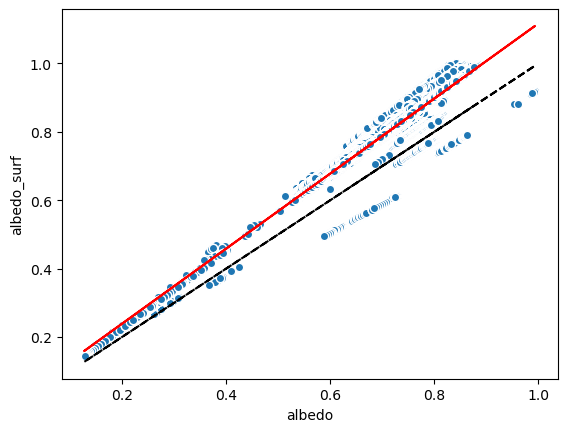

In [75]:
ds_bbr.plot.scatter(
    x='albedo',
    y='albedo_surf',
)

from scipy.stats import linregress

x = ds_bbr['albedo'].values
y = ds_bbr['albedo_surf'].values
nan_mask = np.isnan(x) | np.isnan(y)
x = x[~nan_mask]
y = y[~nan_mask]
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(f"Slope: {slope}, Intercept: {intercept}, R-squared: {r_value**2}")
plt.plot(x, slope * x + intercept, color='red', label='Fitted line')
print(f"R-squared: {r_value**2}")
print(f'RMSE: {np.sqrt(np.mean((y - (slope * x + intercept))**2))}')

print(f'formula: y = {slope:.4f} * x + {intercept:.4f}')
# 1:1
plt.plot(x, x, color='black', linestyle='--', label='1:1 line')



In [76]:
ds_bbr.to_netcdf(
    '/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bbr_HALO_albedo_corr_3.nc',
    mode='w',
    format='NETCDF4',
    unlimited_dims='time',
    encoding={'time': {'units': 'seconds since 1970-01-01T00:00:00Z'}}
)

/tmp/ipykernel_2628239/1884931321.py:1: UserWarning: Times can't be serialized faithfully to int64 with requested units 'seconds since 1970-01-01T00:00:00+00:00'. Resolution of 'milliseconds' needed. Serializing times to floating point instead. Set encoding['dtype'] to integer dtype to serialize to int64. Set encoding['dtype'] to floating point dtype to silence this warning.
  ds_bbr.to_netcdf(


## Examine other aspects of the simulation results

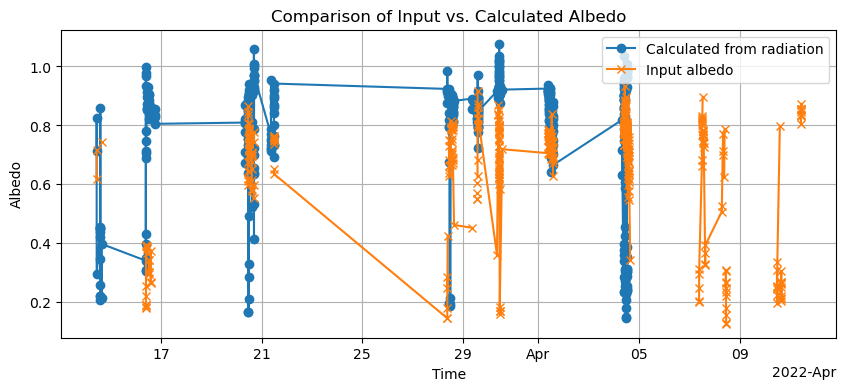

In [27]:
# Calculate albedo as ratio of upward to downward radiation
if 'eup' in ds_sim and 'eglo' in ds_sim:
    if 'altitude' in ds_sim.dims:
        # Calculate at the surface level
        surface_level = 0.0
        calculated_albedo = ds_sim.eup.sel(altitude=surface_level) / ds_sim.eglo.sel(altitude=surface_level)
        
        # Compare with input albedo
        plt.figure(figsize=(10, 4))
        calculated_albedo.plot(marker='o', label='Calculated from radiation')
        ds_crop.albedo.plot(marker='x', label='Input albedo')
        plt.title('Comparison of Input vs. Calculated Albedo')
        plt.xlabel('Time')
        plt.ylabel('Albedo')
        plt.legend()
        plt.grid(True)
        plt.show()

## Load and analyze solar flux for comparison

In [28]:
# Load the solar flux data from Gueymard 2003 dataset
import pandas as pd

ds_e0 = pd.read_csv('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat', skiprows=22, sep='\s+', names=['wavelength', 'flux'], header=None).set_index('wavelength').to_xarray()

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2628239/782123713.py:4: SyntaxWarning: invalid escape sequence '\s'
  ds_e0 = pd.read_csv('/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat', skiprows=22, sep='\s+', names=['wavelength', 'flux'], header=None).set_index('wavelength').to_xarray()


In [29]:
# Integrate over the wavelength range if we have spectral data
if 'wavelength' in ds_sim.dims:
    ds_glo_integrated = ds_sim['edir'].sel(wavelength=ds_sim.wavelength).integrate('wavelength').values
    ds_e0_integrated = ds_e0.sel(wavelength=ds_sim.wavelength, method='nearest').flux.integrate('wavelength').values
    
    print(f"Ratio of integrated direct irradiance to solar flux: {ds_glo_integrated / ds_e0_integrated}")

In [30]:
# Plot the spectral ratio if available
if 'wavelength' in ds_sim.dims:
    plt.figure(figsize=(10, 6))
    (ds_sim['edir'] / ds_e0.sel(wavelength=ds_sim.wavelength, method='nearest').flux).plot()
    plt.title('Spectral Transmittance')
    plt.ylabel('Transmittance')
    plt.xlabel('Wavelength (nm)')
    plt.grid(True)

## Load the original BBR data for comparison

In [ ]:
# Reload the full BBR dataset for comparison with our simulation results
bbr_halo = xr.open_dataset('/projekt_agmwend/home_rad/Joshua/HALO-AC3_unified_data/unified_bbr_HALO.nc')